# EDA - Products Dataset
Phân tích khám phá dữ liệu sản phẩm Shopee đã crawl.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('shopee_data/products.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (17458, 14)


,product_id,shop_id,shop_location,product_name,category,sub_category,original_price,current_price,discount_percentage,historical_sold,rating_average,is_sold_out,liked_count,crawled_at
0,20478055681,962733632,NaN,Nơ cài cổ áo màu đen thời trang lịch lãm cho nam,Thời trang Nam,Cà vạt & Nơ cổ,38232.0,38232.0,0,6000,4.876190,False,134,2026-03-07T21:13:12.024429
1,16494811244,1008809970,Nước ngoài,Cà Vạt Nam Bản Nhỏ 8cm Có Khóa Kéo Màu Đỏ Đen ...,Thời trang Nam,Cà vạt & Nơ cổ,54000.0,53000.0,2,10000,4.828411,False,413,2026-03-07T21:13:12.024447
2,21922796676,322530470,Nước ngoài,Cà vạt EFAN vải lụa dệt jacquard nhiều màu tùy...,Thời trang Nam,Cà vạt & Nơ cổ,59399.0,59399.0,0,3000,4.950570,False,391,2026-03-07T21:13:12.024454
3,28227765200,183199642,Hà Tĩnh,Cà vạt thắt sẵn bản 8cm dành cho người bận rộn...,Thời trang Nam,Cà vạt & Nơ cổ,59000.0,38940.0,34,652,4.764045,False,6,2026-03-07T21:13:12.024461
4,17898918694,308456542,NaN,Cà Vạt Nơ Màu Đen Thời Trang Công Sở Cho Nam vn,Thời trang Nam,Cà vạt & Nơ cổ,45700.0,45700.0,0,379,4.850000,False,16,2026-03-07T21:13:12.024467


## 1. Thông tin tổng quan

In [2]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values')
print(f'\n=== Duplicates ===')
print(f'Duplicate product_id: {df.duplicated(subset="product_id").sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

=== Data Types ===
product_id               int64
shop_id                  int64
shop_location           object
product_name            object
category                object
sub_category            object
original_price         float64
current_price          float64
discount_percentage      int64
historical_sold          int64
rating_average         float64
is_sold_out               bool
liked_count              int64
crawled_at              object
dtype: object

=== Missing Values ===
shop_location    6480
dtype: int64

=== Duplicates ===
Duplicate product_id: 0
Duplicate rows: 0


In [3]:
df.describe()

,product_id,shop_id,original_price,current_price,discount_percentage,historical_sold,rating_average,liked_count
count,1.745800e+04,1.745800e+04,1.745800e+04,1.745800e+04,17458.000000,1.745800e+04,17458.000000,17458.000000
mean,1.941969e+10,4.342179e+08,2.120194e+05,1.556101e+05,24.156318,1.824617e+04,4.825473,3353.549891
std,9.547888e+09,3.953454e+08,2.766114e+05,2.302663e+05,19.867834,5.689014e+04,0.207258,7130.099685
min,1.412997e+07,2.963800e+04,1.080000e+03,1.000000e+03,0.000000,0.000000e+00,0.000000,0.000000
25%,1.201424e+10,8.091946e+07,6.900000e+04,5.000000e+04,0.000000,1.000000e+03,4.787634,78.000000
50%,2.186000e+10,3.074680e+08,1.570000e+05,1.094900e+05,25.000000,8.000000e+03,4.866667,558.000000
75%,2.567321e+10,7.183728e+08,2.700000e+05,1.860300e+05,41.000000,2.000000e+04,4.918159,3331.750000
max,5.815632e+10,1.686490e+09,8.367000e+06,6.900000e+06,99.000000,4.000000e+06,5.000000,156920.000000


## 2. Phân bố theo Category / Sub-category

In [4]:
print('=== Products per Category ===')
print(df['category'].value_counts())
print(f'\n=== Products per Sub-category (top 15) ===')
print(df['sub_category'].value_counts().head(15))

=== Products per Category ===
category
Thời trang Nam    9231
Thời trang Nữ     8227
Name: count, dtype: int64

=== Products per Sub-category (top 15) ===
sub_category
Khác                       837
Áo                         814
Cà vạt & Nơ cổ             492
Vải                        467
Trang Phục Ngành Nghề      466
Đồ Ngủ                     458
Phụ Kiện Nam               458
Trang Sức Nam              457
Trang Phục Truyền Thống    455
Thắt Lưng Nam              450
Đồ Hóa Trang               448
Kính Mắt Nam               448
Đồ Lót                     447
Quần Jeans                 446
Áo Ba Lỗ                   444
Name: count, dtype: int64


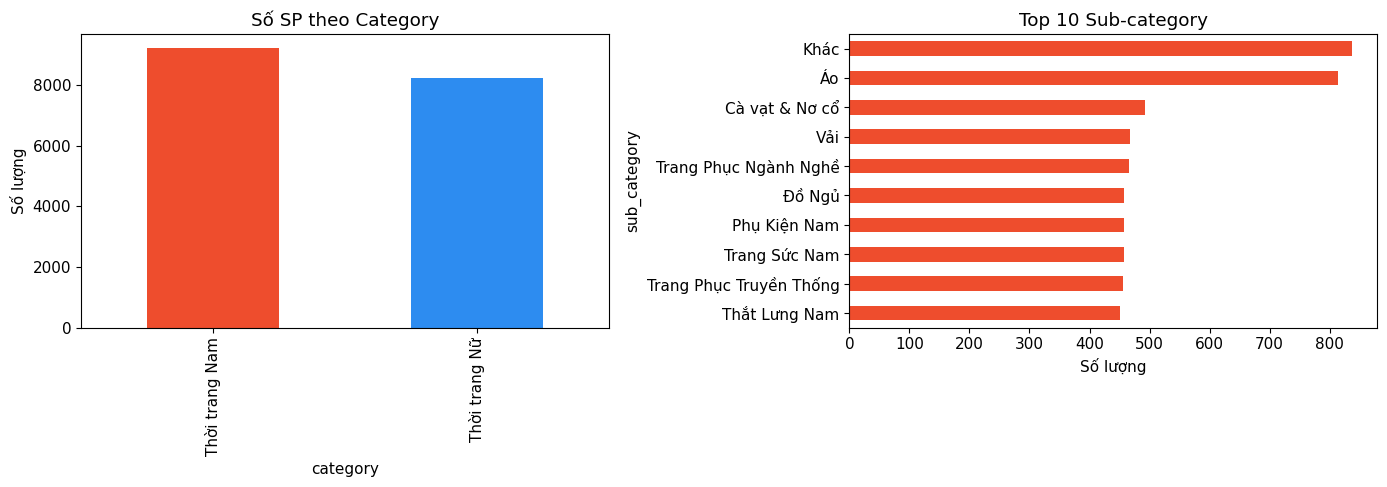

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['category'].value_counts().plot(kind='bar', ax=axes[0], color=['#ee4d2d', '#2d8cf0'])
axes[0].set_title('Số SP theo Category')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=90)

df['sub_category'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#ee4d2d')
axes[1].set_title('Top 10 Sub-category')
axes[1].set_xlabel('Số lượng')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Phân bố giá

In [6]:
print('=== Price Stats (VND) ===')
for col in ['current_price', 'original_price']:
    print(f'\n{col}:')
    print(f'  Min:    {df[col].min():>12,.0f}')
    print(f'  Median: {df[col].median():>12,.0f}')
    print(f'  Mean:   {df[col].mean():>12,.0f}')
    print(f'  Max:    {df[col].max():>12,.0f}')

=== Price Stats (VND) ===

current_price:
  Min:           1,000
  Median:      109,490
  Mean:        155,610
  Max:       6,900,000

original_price:
  Min:           1,080
  Median:      157,000
  Mean:        212,019
  Max:       8,367,000


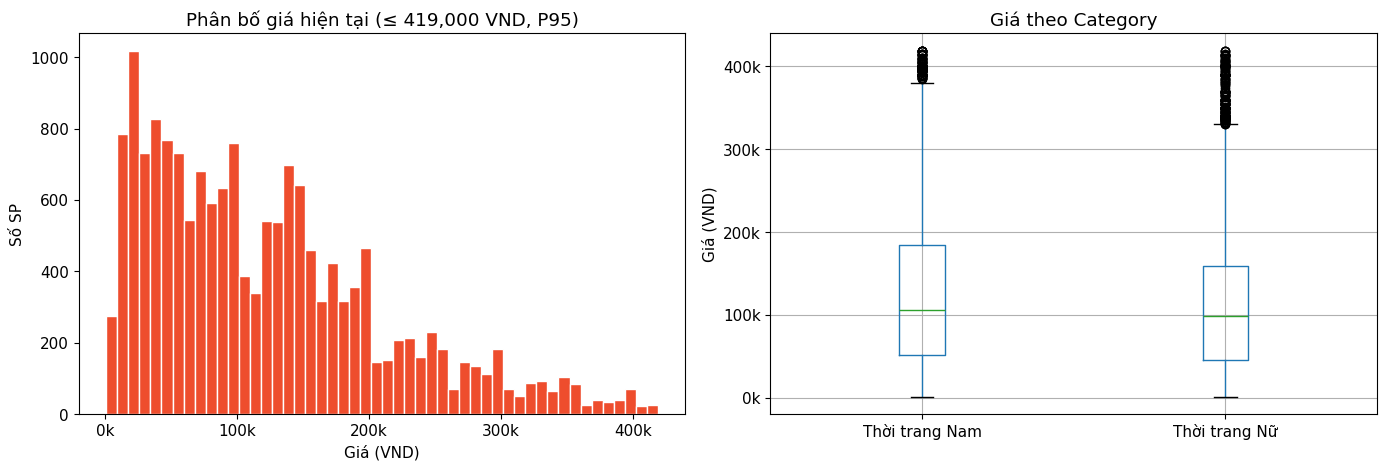

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lọc outlier (lấy percentile 95)
p95 = df['current_price'].quantile(0.95)
df_price = df[df['current_price'] <= p95]

axes[0].hist(df_price['current_price'], bins=50, color='#ee4d2d', edgecolor='white')
axes[0].set_title(f'Phân bố giá hiện tại (≤ {p95:,.0f} VND, P95)')
axes[0].set_xlabel('Giá (VND)')
axes[0].set_ylabel('Số SP')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Boxplot giá theo category
df_price.boxplot(column='current_price', by='category', ax=axes[1])
axes[1].set_title('Giá theo Category')
axes[1].set_xlabel('')
axes[1].set_ylabel('Giá (VND)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. Discount

SP có giảm giá: 13089 / 17458 (75.0%)
Discount trung bình (SP có giảm): 32.2%
Discount median: 33.0%


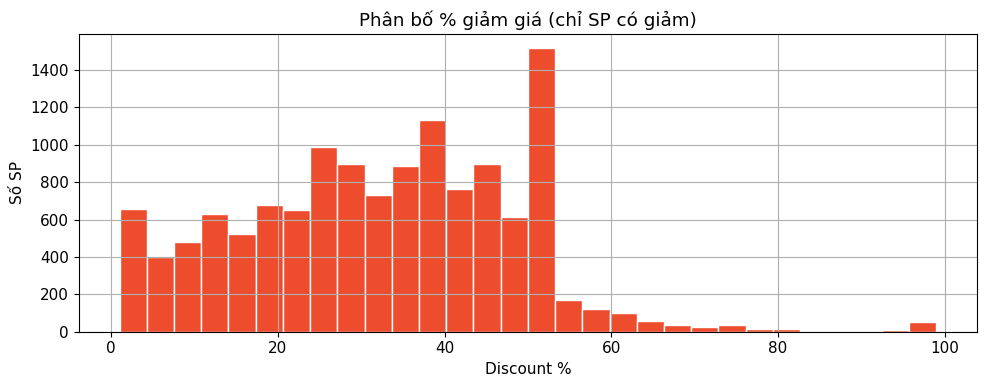

In [8]:
has_discount = df[df['discount_percentage'] > 0]
print(f'SP có giảm giá: {len(has_discount)} / {len(df)} ({len(has_discount)/len(df)*100:.1f}%)')
print(f'Discount trung bình (SP có giảm): {has_discount["discount_percentage"].mean():.1f}%')
print(f'Discount median: {has_discount["discount_percentage"].median():.1f}%')

fig, ax = plt.subplots(figsize=(10, 4))
has_discount['discount_percentage'].hist(bins=30, color='#ee4d2d', edgecolor='white', ax=ax)
ax.set_title('Phân bố % giảm giá (chỉ SP có giảm)')
ax.set_xlabel('Discount %')
ax.set_ylabel('Số SP')
plt.tight_layout()
plt.show()

## 5. Rating & Sold

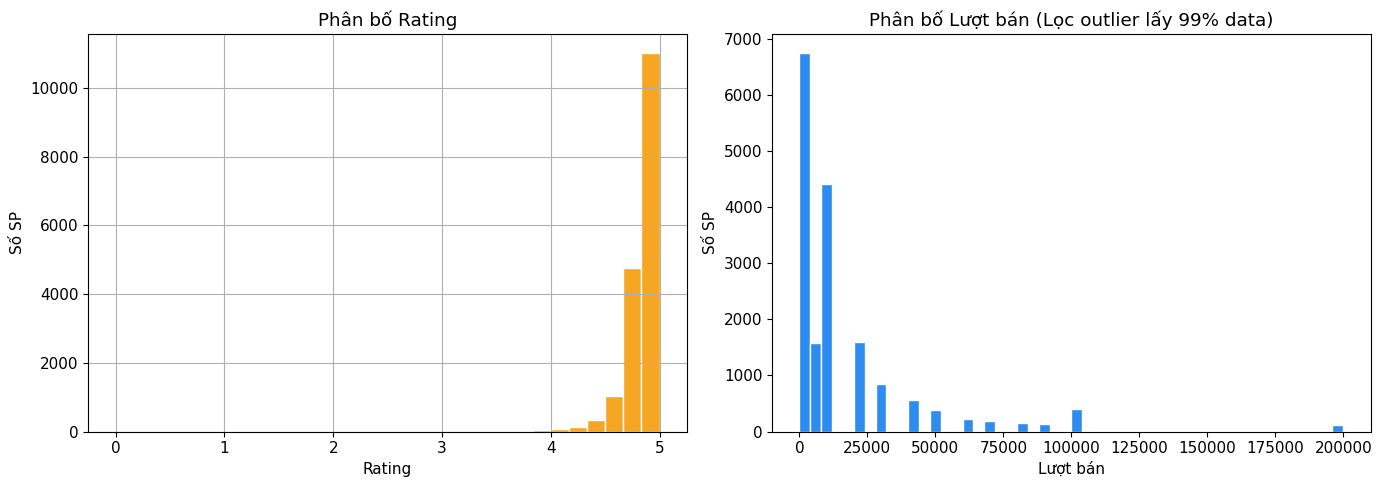

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['rating_average'].hist(bins=30, color='#f5a623', edgecolor='white', ax=axes[0])
axes[0].set_title('Phân bố Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Số SP')

p95 = df['historical_sold'].quantile(0.99)  # Lọc outlier (lấy percentile 99)
df_sold = df[df['historical_sold'] <= p95]
axes[1].hist(df_sold['historical_sold'], bins=50, color='#2d8cf0', edgecolor='white')
axes[1].set_title('Phân bố Lượt bán (Lọc outlier lấy 99% data)')
axes[1].set_xlabel('Lượt bán')
axes[1].set_ylabel('Số SP')

plt.tight_layout()
plt.show()

## 6. Top sản phẩm

In [10]:
cols = ['product_name', 'category', 'sub_category', 'current_price', 'historical_sold', 'rating_average', 'liked_count']

print('=== Top 10 bán chạy nhất ===')
display(df.nlargest(10, 'historical_sold')[cols])

print('\n=== Top 10 được thích nhiều nhất ===')
display(df.nlargest(10, 'liked_count')[cols])

print('\n=== Top 10 đắt nhất ===')
display(df.nlargest(10, 'current_price')[cols])

=== Top 10 bán chạy nhất ===


,product_name,category,sub_category,current_price,historical_sold,rating_average,liked_count
16074,Quần Lót Nữ Đúc Su thun lạnh không đường may c...,Thời trang Nữ,Đồ lót,17996.0,4000000,4.896204,44761
12735,Tất vớ nam nữ chất liệu vải Hàn co giãn bốn ch...,Thời trang Nữ,Vớ/ Tất,22900.0,2000000,4.922123,30235
12753,Tất vớ nam nữ chất liệu vải Hàn Quốc co giãn b...,Thời trang Nữ,Vớ/ Tất,19502.0,2000000,4.930700,23951
12264,[Mua để nhận quà] len sợi MILK BABY cotton 50 ...,Thời trang Nữ,Vải,5040.0,1000000,4.889031,15943
12319,Len Milk Cotton 50g - Len Milk Mác Đen,Thời trang Nữ,Vải,12750.0,1000000,4.907646,20079
12732,Set 5 10 Đôi Tất cổ cao Nữ trơn cao cấp 3 màu ...,Thời trang Nữ,Vớ/ Tất,1000.0,1000000,4.743804,38382
12890,[Combo 10] Tất Vớ Nam Nữ Cổ Cao Trơn UPPERYOU ...,Thời trang Nữ,Vớ/ Tất,79000.0,1000000,4.927517,23642
16048,Quần Lót Nữ Su Lụa Siêu Mỏng Không lộ viền co ...,Thời trang Nữ,Đồ lót,15997.0,1000000,4.884010,10348
3713,Bộ Pin Áo Điều Hòa hàng chính hãng Gifv F20 Du...,Thời trang Nam,Trang Phục Ngành Nghề,649000.0,900000,4.657986,718
4963,"Tất thể thao nam chuyên nghiệp chạy bộ, bóng r...",Thời trang Nam,Vớ Tất,30240.0,900000,4.814226,620



=== Top 10 được thích nhiều nhất ===


,product_name,category,sub_category,current_price,historical_sold,rating_average,liked_count
334,Nơ đeo cổ nam nữ KING Cavat 2 lớp cao cấp chú ...,Thời trang Nam,Cà vạt & Nơ cổ,10683.0,30000,4.929127,156920
10836,Quần ống rộng suông khoá trước ruby chất vải m...,Thời trang Nữ,Quần,64999.0,300000,4.892462,108428
3515,"THẮT LƯNG NAM KHÓA TỰ ĐỘNG CAO CẤP, DÂY NỊT NA...",Thời trang Nam,Thắt Lưng Nam,18620.0,20000,4.854773,101141
3529,[CHÍNH HÃNG] Thắt Lưng Nam Khóa Tự Động Cao Cấ...,Thời trang Nam,Thắt Lưng Nam,24000.0,2000,4.799363,93624
9674,Chân Váy Chữ A Ngắn Có Túi 2 Bên Cạp Chất UMI ...,Thời trang Nữ,Chân váy,139000.0,10000,4.912049,84975
5743,"<Mới>Áo sơ mi nam trơn dài tay, gấp hộp, áo sơ...",Thời trang Nam,Áo,115000.0,10000,4.924878,84125
2100,"[HÀNG XỊN ] Quần âu nam, quần tây nam chất vải...",Thời trang Nam,Quần Dài/Quần Âu,245000.0,30000,4.917772,78851
11104,Quần Jeans Ống Suông Ver 1 Calem.Club nhiều mà...,Thời trang Nữ,Quần jeans,179000.0,200000,4.900982,77243
14244,Áo len nữ màu trắng be xanh tím phom rộng swea...,Thời trang Nữ,Áo len & Cardigan,240999.0,10000,4.761790,76650
10949,quần ống rộng suông nữ lưng cao khóa trước 1 k...,Thời trang Nữ,Quần,84500.0,300000,4.863238,76245



=== Top 10 đắt nhất ===


,product_name,category,sub_category,current_price,historical_sold,rating_average,liked_count
12144,"ẢNH THẬT SHOP _ Váy cưới , sang chảnh, váy lễ ...",Thời trang Nữ,Váy cưới,6900000.0,64,5.000000,2272
4818,"Dây chuyền bạc nam ống rồng cuốn, vòng cổ nam ...",Thời trang Nam,Trang Sức Nam,5689560.0,1000,4.962406,719
12008,"Váy Cưới Làm Lễ, Đầm Cưới Đi Tiệc, Dài Tay Phố...",Thời trang Nữ,Váy cưới,5250000.0,108,5.000000,105
8207,"Xe xuồng điện trẻ em chơi công viên, quảng trư...",Thời trang Nam,Đồ Hóa Trang,4590000.0,1000,5.000000,10
11990,"Váy Cưới Làm Lễ, Đầm Cưới Đi Tiệc, Dáng Xoè, D...",Thời trang Nữ,Váy cưới,4500000.0,139,5.000000,103
12082,"Váy Cưới Đi Bàn, Đầm Cưới Đuôi Cá, Cúp Ngực, D...",Thời trang Nữ,Váy cưới,4500000.0,156,5.000000,67
12024,"Váy Cưới Làm Lễ, Đầm Cưới Đi Tiệc, Dài Tay, Vả...",Thời trang Nữ,Váy cưới,4390000.0,104,5.000000,32
7405,Áo Vest Nam Trẻ Trung Cao Cấp DEZI AV-19-0032 ...,Thời trang Nam,Áo Vest và Blazer,4000000.0,2000,5.000000,21
12086,"Váy cưới, váy tiệc, váy chụp ảnh cưới hoa nổi ...",Thời trang Nữ,Váy cưới,3990000.0,152,5.000000,2208
12068,"Váy Cưới Làm Lễ, Đầm cưới Đính Hoa 3D, Cúp Ngự...",Thời trang Nữ,Váy cưới,3950000.0,350,5.000000,1024


## 7. Sold Out & Unique Shops

In [11]:
sold_out = df['is_sold_out'].sum()
print(f'Hết hàng: {sold_out} / {len(df)} ({sold_out/len(df)*100:.1f}%)')
print(f'Unique shops: {df["shop_id"].nunique()}')
print(f'\n=== Shop có nhiều SP nhất (top 10) ===')
print(df['shop_id'].value_counts().head(10))

Hết hàng: 0 / 17458 (0.0%)
Unique shops: 5638

=== Shop có nhiều SP nhất (top 10) ===
shop_id
35296526     109
684640396    105
24710134      86
24341415      83
58503290      78
30848498      57
322530470     56
232434430     56
39923306      53
196261835     50
Name: count, dtype: int64
